## **Weaker and more frequent Mediterranean sea breezes in a warming climate**

Code by: Shalenys Bedoya-Valestt (CIDE, CSIC-UV-GVA)
<br>01 October 2025
<br>Submitted to *Nature Communications*

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import linregress
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.colors import Normalize

DATA_DIR = './BRISES/data/'
START_DATE = "1981-01-01"
END_DATE = "2021-12-31"

# Coordinates
data_coords = pd.read_csv(DATA_DIR + 'ERA5_Points_MED_landsea.csv',  encoding='latin-1', sep=';')
data_coords.loc[data_coords['ID'] == '8416', 'ID'] = '8416Y'

In [2]:
def compute_trends(da, alpha=0.05, decimals=3):
    out = []
    for v in (da.data_vars if isinstance(da, xr.Dataset) else [da.name or 'var']):
        d = da[v] if isinstance(da, xr.Dataset) else da
        for st in d.station:
            s = d.sel(station=st).dropna('dates')
            if len(s.dates) < 2: continue
            y = pd.to_datetime(s.dates.values).year
            r = linregress(y, s.values)
            trend = 'increasing' if (r.pvalue<alpha and r.slope>0) else 'decreasing' if (r.pvalue<alpha and r.slope<0) else 'no trend'
            lab = '***' if r.pvalue<.001 else '**' if r.pvalue<.01 else '*' if r.pvalue<.05 else '.' if r.pvalue<.1 else 'ns'
            out.append([v, st.item(), trend, round(r.slope*10,decimals), round(r.pvalue,decimals), r.pvalue<alpha, lab])
    return pd.DataFrame(out, columns=['variable','station','trend','slope_decade','p_value','significant','signif_label'])

# Detrend for correlations
def detrend_dim(da, dim="dates", deg=1):
    p = da.polyfit(dim=dim, deg=deg)
    return da - xr.polyval(da[dim], p.polyfit_coefficients)

def detrend_dataset(ds, dim="dates", deg=1):
    detrended = {}
    for var in ds.data_vars:
        detrended[var] = detrend_dim(ds[var], dim=dim, deg=deg)
        
    return xr.Dataset(detrended, coords=ds.coords, attrs=ds.attrs)

### JC classification

In [3]:
# Load JC scheme of days per month
df_JC = pd.read_csv(DATA_DIR + 'JC_class_monthly.csv', index_col='dates', parse_dates=True)

# To xarray
ds_JC = df_JC.reset_index().set_index(['dates', 'station']).to_xarray()

In [4]:
# ------------------------------------------------------
# -------------- Station-scale
# ------------------------------------------------------

# Annual & seasonal means per station
da_JC_annual = ds_JC.resample(dates="Y").sum()
da_JC_seasonal = ds_JC.resample(dates="Q-NOV").sum()
da_JC_seasonal = da_JC_seasonal.drop_sel(dates=np.datetime64("2022-02-28"))

# Annual & seasonal anomalies
clim_JC_annual = da_JC_annual.sel(dates=slice("1981", "2021")).mean("dates")
anom_JC_annual = da_JC_annual - clim_JC_annual

clim_JC_seasonal = da_JC_seasonal.sel(dates=slice("1981", "2021")).groupby("dates.season").mean("dates")
anom_JC_seasonal = da_JC_seasonal.groupby("dates.season") - clim_JC_seasonal


# Annual trends
annual_spatial_trends_JC = compute_trends(anom_JC_annual, decimals=3)

# Seasonal trends
seasonal_spatial_trends_JC = []

for season, da_season in anom_JC_seasonal.groupby('season'):
    df = compute_trends(da_season, decimals=3)
    df['season'] = season
    seasonal_spatial_trends_JC.append(df)
    
seasonal_spatial_trends_JC = pd.concat(seasonal_spatial_trends_JC, ignore_index=True)


In [5]:
# Bins
# [df_A_annual['slope_decade'].min(), df_A_annual['slope_decade'].max()]
# [df_C_annual['slope_decade'].min(), df_C_annual['slope_decade'].max()]
# [df_A_seasonal['slope_decade'].min(), df_A_seasonal['slope_decade'].max()]
# [df_C_seasonal['slope_decade'].min(), df_C_seasonal['slope_decade'].max()]

In [6]:
def plot_trend_maps(df_JC_annual, df_JC_seasonal, coords, alpha=0.05):
    df_A_annual = df_JC_annual.loc[df_JC_annual['variable'] == 'A']
    df_C_annual = df_JC_annual.loc[df_JC_annual['variable'] == 'C']
    df_A_seasonal = df_JC_seasonal.loc[df_JC_seasonal['variable'] == 'A']
    df_C_seasonal = df_JC_seasonal.loc[df_JC_seasonal['variable'] == 'C']

    from matplotlib.colors import to_rgba
    lat, lon = coords['Lat'].values, coords['Lon'].values
    seasons, codes = ['Annual','Winter (DJF)','Spring (MAM)','Summer (JJA)','Autumn (SON)'], ['Annual','DJF','MAM','JJA','SON']

    fig, axes = plt.subplots(2, 5, figsize=(14, 3.2)) 
    plt.subplots_adjust(wspace=0.01, hspace=0.04)

    colors = ['#ff0000','#0000ff','white','white']
    edge_colors = ['#ff0000','#0000ff','#e00a94','#00aaff']
    jc_bins = np.arange(-5.1,6.1,1)
    min_size,max_size =5,40

    def assign_size(df,col,bins):
        df['category'] = pd.cut(df[col], bins=bins, labels=np.arange(len(bins)-1))
        df['size'] = df['category'].astype(float).apply(lambda x: min_size + x*(max_size-min_size)/(len(bins)-2))
        return df

    def plot_map(ax, df, colors, edge_colors, bins, title=None):
        if df is None or len(df)==0: return
        m = Basemap(projection='merc', llcrnrlon=-10.7, urcrnrlon=18.8,
                    llcrnrlat=34, urcrnrlat=46, resolution='i', ax=ax)
        m.fillcontinents(color='#DCDCDC', alpha=0.6, zorder=3)
        ax.set_title(title, fontsize=9, pad=2)
        ax.set_xticks([]); ax.set_yticks([])
        [s.set_visible(False) for s in ax.spines.values()]
        ax.set_facecolor('white')

        if 'Lat' not in df.columns:
            df['Lat'], df['Lon'] = lat[:len(df)], lon[:len(df)]
        df['sig'], df['pos'] = df['p_value']<=alpha, df['slope_decade']>=0
        df = assign_size(df, 'slope_decade', bins)

        def scat(sub, marker, fc, ec, a=0.9):
            if len(sub)==0: return
            x,y = m(sub['Lon'],sub['Lat'])
            m.scatter(x, y, s=sub['size'], marker=marker,
                      facecolors=fc, edgecolors=ec, linewidths=0.8, alpha=a, zorder=5)

        scat(df[df.pos & df.sig], '^', colors[0], edge_colors[0])
        scat(df[df.pos & ~df.sig], '^', colors[2], edge_colors[2])
        scat(df[~df.pos & df.sig], 'v', colors[1], edge_colors[1])
        scat(df[~df.pos & ~df.sig], 'v', colors[3], edge_colors[3])

    # --- Panels: top row = A, bottom row = C
    for j,(label,code) in enumerate(zip(seasons,codes)):
        if code == 'Annual':
            df_s, df_d = df_A_annual, df_C_annual
        else:
            df_s = df_A_seasonal[df_A_seasonal['season']==code]
            df_d = df_C_seasonal[df_C_seasonal['season']==code]

        plot_map(axes[0,j], df_s, colors, edge_colors, jc_bins, title=label)
        plot_map(axes[1,j], df_d, colors, edge_colors, jc_bins)

    # Titles for rows
    axes[0,0].text(-0.25, 0.5, "Anticyclonic", transform=axes[0,0].transAxes,
                   fontsize=11, fontweight='bold', rotation=90, va='center')
    axes[1,0].text(-0.25, 0.5, "Cyclonic", transform=axes[1,0].transAxes,
                   fontsize=11, fontweight='bold', rotation=90, va='center')

    plt.show()
#     fig.savefig(DIR + 'scripts/Fig 5/JC_trends.pdf', format='pdf')

/tmp/ipykernel_1729023/3241180144.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Lat'], df['Lon'] = lat[:len(df)], lon[:len(df)]
/tmp/ipykernel_1729023/3241180144.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Lat'], df['Lon'] = lat[:len(df)], lon[:len(df)]
/tmp/ipykernel_1729023/3241180144.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

/tmp/ipykernel_1729023/3241180144.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Lat'], df['Lon'] = lat[:len(df)], lon[:len(df)]
/tmp/ipykernel_1729023/3241180144.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Lat'], df['Lon'] = lat[:len(df)], lon[:len(df)]
/tmp/ipykernel_1729023/3241180144.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

/tmp/ipykernel_1729023/3241180144.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Lat'], df['Lon'] = lat[:len(df)], lon[:len(df)]
/tmp/ipykernel_1729023/3241180144.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Lat'], df['Lon'] = lat[:len(df)], lon[:len(df)]
/tmp/ipykernel_1729023/3241180144.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

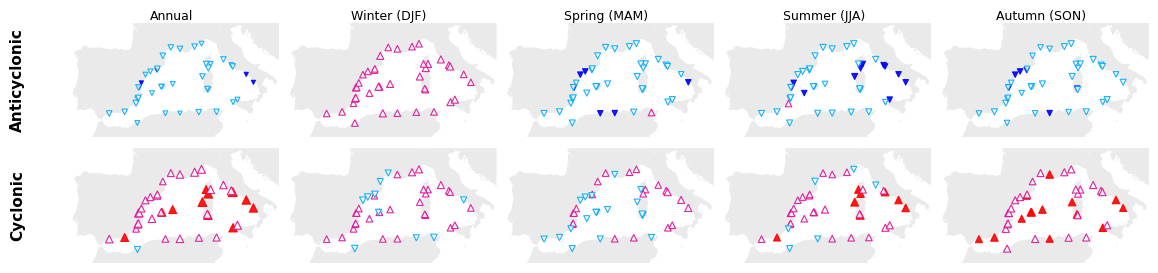

In [7]:
plot_trend_maps(df_JC_annual=annual_spatial_trends_JC,
    df_JC_seasonal=seasonal_spatial_trends_JC,
    coords=data_coords)

### Correlations

In [8]:
# Load SBs data

# ------------------------------------------------------

# Load SBs speeds monthly aggregates after SBs days filtering on wind speed data

# ------------------------------------------------------

df_ws = pd.read_csv(DATA_DIR + 'SBs_speeds_monthly_aggr.csv', index_col='dates') 
df_ws.index = pd.to_datetime(df_ws.index)

# Convert to xarray Dataset
ds_ws = xr.Dataset(
    {"ws": (("dates","station"), df_ws.values)},
    coords={"dates": df_ws.index, "station": df_ws.columns}
)
seasons = ['DJF', 'MAM','JJA','SON']

# ------------------------------------------------------
# -------------- Station-scale
# ------------------------------------------------------

# Annual & seasonal means per station
da_speeds_annual = ds_ws["ws"].resample(dates="Y").mean()
da_speeds_seasonal = ds_ws["ws"].resample(dates="Q-NOV").mean()
da_speeds_seasonal = da_speeds_seasonal.drop_sel(dates=np.datetime64("2022-02-28"))

# Annual & seasonal anomalies
clim_speeds_annual = da_speeds_annual.sel(dates=slice("1981", "2021")).mean("dates")
anom_speeds_annual = da_speeds_annual - clim_speeds_annual

clim_speeds_seasonal = da_speeds_seasonal.sel(dates=slice("1981", "2021")).groupby("dates.season").mean("dates")
anom_speeds_seasonal = da_speeds_seasonal.groupby("dates.season") - clim_speeds_seasonal

# Detrend anomalies
anom_speeds_annual_detrended = detrend_dataset(anom_speeds_annual.to_dataset())

anom_speeds_seasonal_detrended = [detrend_dataset(
    anom_speeds_seasonal.to_dataset().where(anom_speeds_seasonal.season == season_, drop=True)) for season_ in seasons]

# ------------------------------------------------------

# Load SBs days monthly aggregates

# ------------------------------------------------------

df_ds = pd.read_csv(DATA_DIR + 'SBs_days_monthly_aggr.csv', index_col='dates') 
df_ds.index = pd.to_datetime(df_ds.index)

# Convert to xarray Dataset
ds_ds = xr.Dataset(
    {"days": (("dates","station"), df_ds.values)},
    coords={"dates": df_ds.index, "station": df_ds.columns}
)

# ------------------------------------------------------
# -------------- Station-scale
# ------------------------------------------------------

# Annual & seasonal means per station
da_days_annual = ds_ds["days"].resample(dates="Y").sum()
da_days_seasonal = ds_ds["days"].resample(dates="Q-NOV").sum()
da_days_seasonal = da_days_seasonal.drop_sel(dates=np.datetime64("2022-02-28"))

# Annual & seasonal anomalies
clim_days_annual = da_days_annual.sel(dates=slice("1981", "2021")).mean("dates")
anom_days_annual = da_days_annual - clim_days_annual

clim_days_seasonal = da_days_seasonal.sel(dates=slice("1981", "2021")).groupby("dates.season").mean("dates")
anom_days_seasonal = da_days_seasonal.groupby("dates.season") - clim_days_seasonal

# Detrend anomalies
anom_days_annual_detrended = detrend_dataset(anom_days_annual.to_dataset())

anom_days_seasonal_detrended = [detrend_dataset(
    anom_days_seasonal.to_dataset().where(anom_days_seasonal.season == season_, drop=True)) for season_ in seasons]

In [9]:
# Detrend JC class
anom_JC_annual_detrended = detrend_dataset(anom_JC_annual)

anom_JC_seasonal_detrended = [detrend_dataset(
    anom_JC_seasonal.where(anom_JC_seasonal.season == season_, drop=True)) for season_ in seasons]

In [10]:
def concat_seasonal_datasets(seasonal_list, ds_annual=None, seasons=['DJF','MAM','JJA','SON']):
    # Add season coords
    ds_fixed = [ds.assign_coords(season=s).expand_dims('season') for ds, s in zip(seasonal_list, seasons)]
    
    # Add Annual data
    if ds_annual is not None:
        ds_annual = ds_annual.assign_coords(season='Annual').expand_dims('season')
        ds_fixed = [ds_annual] + ds_fixed
    
    # Concatenate
    combined = xr.concat(ds_fixed, dim='season', join='override')
    return combined

In [11]:
# Detrended datasets
JC_detrended_dataset = concat_seasonal_datasets(anom_JC_seasonal_detrended, ds_annual=anom_JC_annual_detrended)
speeds_detrended_dataset = concat_seasonal_datasets(anom_speeds_seasonal_detrended, ds_annual=anom_speeds_annual_detrended)
days_detrended_dataset = concat_seasonal_datasets(anom_days_seasonal_detrended, ds_annual=anom_days_annual_detrended)

In [12]:
def pearson_corr(ds_x, ds_y, var_x, var_y, group='season'):
    from scipy.stats import pearsonr

    results = []
    for st in ds_x.station.values:
        for s in np.unique(ds_x[group]):
            a = ds_x[var_x].sel(station=st, season=s)
            b = ds_y[var_y].sel(station=st, season=s)
            a, b = xr.align(a, b, join="inner")
            if len(a) > 1:
                mask =  ~np.logical_or(np.isnan(a.data), np.isnan(b.data))
                # mask array is now true where ith rows of df and dg are NOT nan.
                X = a.data[mask]  # this returns a 1D array of length mask.sum()
                Y = b.data[mask]
                r, p = pearsonr(X, Y)
                results.append([st, s, r, p])
    return pd.DataFrame(results, columns=["station", group, "r", "p_value"])

# Pearson correlations
variables = ['A','C']

speeds_JC_corr = [pearson_corr(speeds_detrended_dataset, JC_detrended_dataset, 'ws', var , 'season') for var in variables]
speeds_JC_corr = pd.concat(speeds_JC_corr, axis=0,keys=variables).reset_index(level=0, names='variable')

days_JC_corr = [pearson_corr(days_detrended_dataset, JC_detrended_dataset, 'days', var , 'season') for var in variables]
days_JC_corr = pd.concat(days_JC_corr, axis=0,keys=variables).reset_index(level=0, names='variable')

# Join corr_datasets
df_corr = pd.concat([speeds_JC_corr, days_JC_corr], keys=['speeds', 'days'])
df_corr = df_corr.reset_index(level=1, drop=True)

In [13]:
def plot_corr_maps_type(df_corr, coords, variables, corr_type='speeds', alpha=0.05, title=None):
    from matplotlib.colors import to_rgba
    from mpl_toolkits.basemap import Basemap
    import matplotlib.pyplot as plt

    df_corr = df_corr[df_corr.index == corr_type]  # filter by 'speeds' or 'days'
    lat, lon = coords['Lat'].values, coords['Lon'].values
    seasons, codes = ['Annual','Winter (DJF)','Spring (MAM)','Summer (JJA)','Autumn (SON)'], ['Annual','DJF','MAM','JJA','SON']
    fig, axes = plt.subplots(2, 5, figsize=(14, 3.2),sharey='all',sharex=True) 
    plt.subplots_adjust(wspace=0.01, hspace=0.04)

    colors = ['#ff0000','#0000ff','#e00a94','#00aaff']

    for i,(label,code) in enumerate(zip(seasons,codes)):
        for j,var in enumerate(variables):
            axes[0,0].set_ylabel('Anticyclone')
            axes[1,0].set_ylabel('Cyclone')
            
            ax = axes[j,i]
            m = Basemap(projection='merc', llcrnrlon=-10.7, urcrnrlon=18.8,
                        llcrnrlat=34, urcrnrlat=46, resolution='i', ax=ax)
            m.fillcontinents(color='#DCDCDC', alpha=0.6, zorder=3)
            ax.set_xticks([]); ax.set_yticks([]); [s.set_visible(False) for s in ax.spines.values()]
            ax.set_facecolor('white')
            
            if code=='Annual':
                df = df_corr[df_corr['season']=='Annual']
            else:
                df = df_corr[df_corr['season']==code]
            df = df[df['variable']==var]

            if len(df)==0: continue
            df = df.copy()
            df['Lat'], df['Lon'] = lat[:len(df)], lon[:len(df)]
            df['sig'] = df['p_value'] <= alpha
            df['pos'] = df['r'] >= 0

            def scat(sub, marker, fc,ap):
                if len(sub)==0: return
                x, y = m(sub['Lon'], sub['Lat'])
                m.scatter(x, y, s=30, marker=marker, facecolors=fc, linewidths=1, zorder=5, alpha=ap)

            scat(df[df.pos & df.sig], '+', colors[0],ap=1)
            scat(df[df.pos & ~df.sig], '+', colors[2],ap=0.25)
            scat(df[~df.pos & df.sig], 0, colors[1],ap=1)
            scat(df[~df.pos & ~df.sig], 0, colors[3],ap=0.25)

            if j==0: ax.text(0.1,1.1,label, transform=ax.transAxes, fontsize=10, fontweight='bold', rotation=None, va='center')

    plt.show()
#     fig.savefig(DIR + 'scripts/Fig 5/JC_corr_' + corr_type + '.pdf', format='pdf')

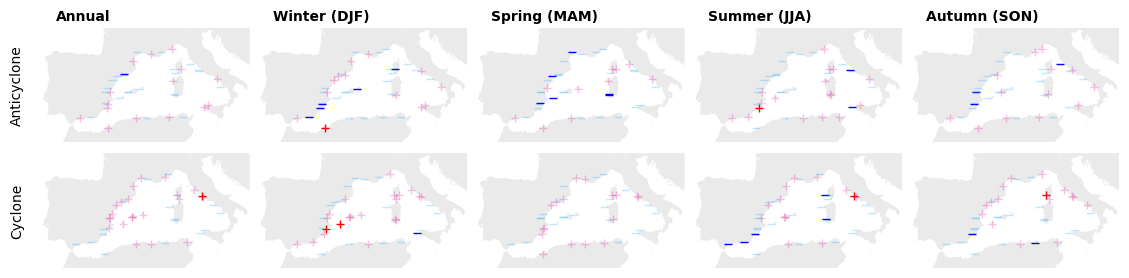

In [14]:
# Speeds
plot_corr_maps_type(df_corr, data_coords, variables, corr_type='speeds')


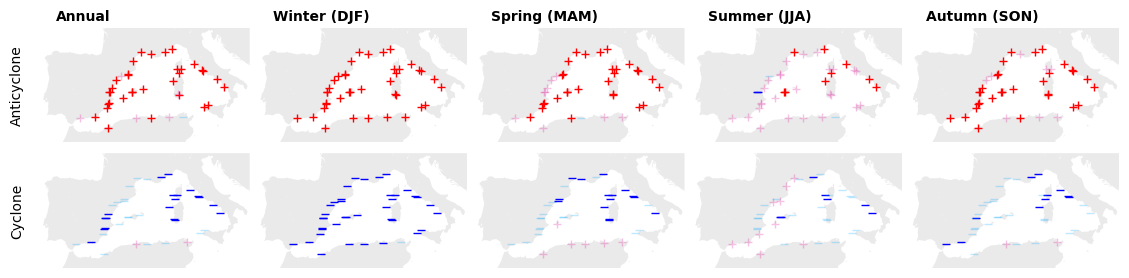

In [15]:
# Occurrence
plot_corr_maps_type(df_corr, data_coords, variables, corr_type='days')

### Cluster composites

In [16]:
# Load SBs days monthly aggregates
df_ds = pd.read_csv(DATA_DIR + 'SBs_days_monthly_aggr.csv', index_col='dates') 
df_ds.index = pd.to_datetime(df_ds.index)

# Convert to xarray Dataset
ds_ds = xr.Dataset(
    {"days": (("dates","station"), df_ds.values)},
    coords={"dates": df_ds.index, "station": df_ds.columns}
)

da_ds = ds_ds.mean(dim='station')
clim_days_monthly_mean = da_ds.sel(dates=slice("1981", "2021")).groupby("dates.month").mean("dates")
clim_days_monthly_std = da_ds.sel(dates=slice("1981", "2021")).groupby("dates.month").std("dates")
# standardized anomalies
stand_anom_days_monthly = xr.apply_ufunc(lambda x, m, s: (x - m) / s, da_ds.groupby("dates.month"), clim_days_monthly_mean, clim_days_monthly_std) 

# Q90
p90 = stand_anom_days_monthly.groupby('dates.month').quantile(0.9)
stand_anom_days_monthly_q90 = stand_anom_days_monthly.where(stand_anom_days_monthly.groupby('dates.month') > p90, drop=True)

extreme_winter_months = stand_anom_days_monthly_q90.sel(dates=stand_anom_days_monthly_q90.dates.dt.month.isin([12,1,2]))

### large-scale circulation

In [44]:
# Compressed dataset

# # Load filtered SBs days winter anomalies of 'Z500','MSLP','TCC','850T','T2M','SST'
# ds_ls = joblib.load(DATA_DIR + 'ERA5_daily_anomalies_DJF_large_scale.pkl')
# # Load JC
# ds_jc_sb = joblib.load(DATA_DIR + '11JC_daily_DJF.pkl')
# # Merge
# ds_ls_jc = xr.merge([ds_ls,ds_jc_sb])

# # Ensure all data use float32 to save space
# # (CT can stay float64 if it’s categorical or contains NaN placeholders)
# for var in ds_ls_jc.data_vars:
#     if ds_ls_jc[var].dtype == "float64" and var != "CT":
#         ds_ls_jc[var] = ds_ls_jc[var].astype("float32")

# # Define compression and chunking settings
# comp = dict(zlib=True, complevel=5)
# encoding = {
#     var: {**comp, "chunksizes": (100, 90, 115)}
#     for var in ds_ls_jc.data_vars
# }

# # Save to compressed NetCDF
# output_file = DATA_DIR+ "ERA5_daily_anomalies_DJF_large_scale_compressed.nc"
# ds_ls_jc.to_netcdf(output_file, encoding=encoding)

In [17]:
ds_ls_jc = xr.open_dataset(DATA_DIR + "ERA5_daily_anomalies_DJF_large_scale_compressed.nc")
ds_ls_jc = ds_ls_jc_.load()

variables = ['gh','msl','t2m','t','sst','tcc','CT']

# Filter anomalous winter months (Q90)
pairs = [(int(d.dt.year), int(d.dt.month)) for d in extreme_winter_months.dates]

mask = False
for y, m in pairs:
    mask = mask | ((ds_ls_jc.time.dt.year == y) & (ds_ls_jc.time.dt.month == m))

ds_ls_extreme = ds_ls_jc.sel(time=mask)

# Stack anomalies on time x spatial
ds_ls_extreme_stacked = ds_ls_extreme.stack(spatial=("latitude","longitude")).transpose("time","spatial")

In [18]:
# =====================================================
# KMEANS FUNCTION (with SST special case)
# =====================================================
def multivariate_kmeans(ds, variables, n_clusters=2):
    results = {}

    for var in variables:
        print(f"Processing {var}...")

        # === CASE 1: all variables except SST and CT ===
        if var not in ['sst', 'CT']:
            spatial_mask = ds[var].isel(time=0)
            X = ds[var].dropna(dim='time', how='all')

            # Fit KMeans
            kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(X.data)
            labels = kmeans.labels_
            sil_score = silhouette_score(X.data, labels, metric='euclidean')

            # Compute cluster composites
            composites = []
            for i in range(n_clusters):
                cluster_mask = (labels == i)
                composite = np.mean(X.data[cluster_mask], axis=0)
                composites.append(composite)

            # Convert composites to DataArrays
            composite_3d = [
                xr.DataArray(
                    comp,
                    dims=["spatial_points"],
                    coords={"spatial_points": spatial_mask.spatial.rename({"spatial": "spatial_points"})}
                ).unstack("spatial_points")
                for comp in composites
            ]

        # === CASE 2: SST or CT ===
        else:
            X = ds[var].dropna(dim='time', how='all')

            # Mask valid (non-NaN) points
            spatial_mask = ~np.isnan(X.isel(time=0))
            valid_mask = spatial_mask.data
            valid_data = X[:, valid_mask]

            # Fit KMeans
            kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(valid_data)
            labels = kmeans.labels_
            sil_score = silhouette_score(valid_data, labels, metric='euclidean')

            # Compute composites
            composites = []
            for i in range(n_clusters):
                composite = np.nanmean(valid_data[labels == i], axis=0)
                composite_full = np.full(spatial_mask.shape, np.nan)
                composite_full[valid_mask] = composite
                composites.append(composite_full)

            # Convert composites to DataArrays
            composite_3d = [
                xr.DataArray(
                    comp,
                    dims=["spatial"],
                    coords={"spatial": X.spatial}
                ).unstack("spatial")
                for comp in composites
            ]

        # Cluster frequencies (%)
        total_days = len(X.time)
        freq_cluster = [np.round((np.sum(labels == i) * 100) / total_days, 1) for i in range(n_clusters)]

        # Monthly frequencies
        month_freq = [X.time[labels == i].dt.month for i in range(n_clusters)]
        days_class = []
        for months in month_freq:
            unique, counts = np.unique(months, return_counts=True)
            days_class.append(dict(zip(unique, counts)))

        # Save results
        results[var] = {
            "composites": composite_3d,
            "labels": labels,
            "freq": freq_cluster,
            "silhouette": sil_score,
            "monthly_counts": days_class
        }

    return results

# =====================================================
# FUNCTION TO ORGANIZE COMPOSITES FOR PLOTTING
# =====================================================
def prepare_composites_for_plot(results, variables, n_clusters):
    """
    Reorganizes the dictionary results[var]['composites'] into
    a list of composites per cluster.
    """
    composites_by_cluster = []
    for i in range(n_clusters):
        comp_dict = {}
        for var in variables:
            comp_dict[var] = results[var]['composites'][i]
        composites_by_cluster.append(comp_dict)

    # Frequencies (assuming same clusters across variables)
    freqs = results[variables[0]]['freq']
    return composites_by_cluster, freqs

#===========================================
# PLOT
#===========================================

# Custom norm for diverging maps around zero
class StretchOutNormalize(Normalize):
    def __init__(self, vmin=None, vmax=None, low=None, up=None, clip=False):
        self.low = low
        self.up = up
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x = [self.vmin, self.low, self.up, self.vmax]
        y = [0, 0.5-1e-9, 0.5+1e-9, 1]
        return np.ma.masked_array(np.interp(value, x, y))

def plot_all_variables(
    composites, variables, freqs, 
    colormaps=None, counts=None, npas=None, vmins=None, vmaxs=None, tick_arrays=None
):
    """
    Plots all variables for each cluster in a single figure with variable-specific settings.
    """
    n_clusters = len(composites)
    n_vars = len(variables)

    # Default settings
    colormaps = colormaps or ['RdBu_r'] * n_vars
    counts = counts or [0] * n_vars
    npas = npas or [0] * n_vars
    vmins = vmins or [None] * n_vars
    vmaxs = vmaxs or [None] * n_vars
    tick_arrays = tick_arrays or [None] * n_vars

    plt.close("all")
    plt.rc("axes", linewidth=2, edgecolor="k")
    plt.rc('font', size=10)
    mpl.rcParams['legend.numpoints'] = 1

    fig, axs = plt.subplots(n_clusters, n_vars, figsize=(4*n_vars, 4*n_clusters))
    axs = np.array(axs).reshape(n_clusters, n_vars)
    h = 2000.

    for i, comp in enumerate(composites):
        for j, var in enumerate(variables):
            ax = axs[i, j]

            # Set min/max from composites if not provided
            data = comp[var].data
            vmin = vmins[j] if vmins[j] is not None else np.nanmin(data)
            vmax = vmaxs[j] if vmaxs[j] is not None else np.nanmax(data)
            low = -npas[j] if npas[j] is not None else 0
            up = npas[j] if npas[j] is not None else 0
            levels = np.arange(vmin,vmax + npas[j], npas[j])
            # Norm: only apply StretchOutNormalize for variables other than CT
            if var != "CT":
                norm = StretchOutNormalize(vmin=vmin, vmax=vmax, low=low, up=up)
            else:
                norm = None  # Use default linear scaling
            # Map setup
            m = Basemap(projection='nsper', lon_0=8, lat_0=46,
                        satellite_height=h*1000., resolution='l', ax=ax)
            m.drawcoastlines()

            lon, lat = np.meshgrid(comp[var].longitude, comp[var].latitude)
            xi, yi = m(lon, lat)

            # Plot filled contours
            im = m.contourf(xi, yi, data, levels=levels, cmap=colormaps[j], norm=norm, extend='both')

            # Optional contour lines for geopotential or similar
            if counts[j] == 1:
                cnt = m.contour(xi, yi, data, colors='lightgray', linewidths=0.7)
                ax.clabel(cnt, cnt.levels, inline=True, fontsize=8)

            ax.set_title(f"{var.upper()} (Cluster {i+1}, {freqs[i]}%)")

            # Set colorbar for this subplot
            cbar = fig.colorbar(im, ax=ax, shrink=0.8)
            if tick_arrays[j] is not None:
                cbar.set_ticks(tick_arrays[j])

    plt.tight_layout()
    plt.show()
#     fig.savefig(DIR + 'scripts/Fig 5/CLuster_composites.pdf', format='pdf')


Processing gh...
Processing msl...
Processing tcc...
Processing t...
Processing t2m...
Processing sst...
Processing CT...


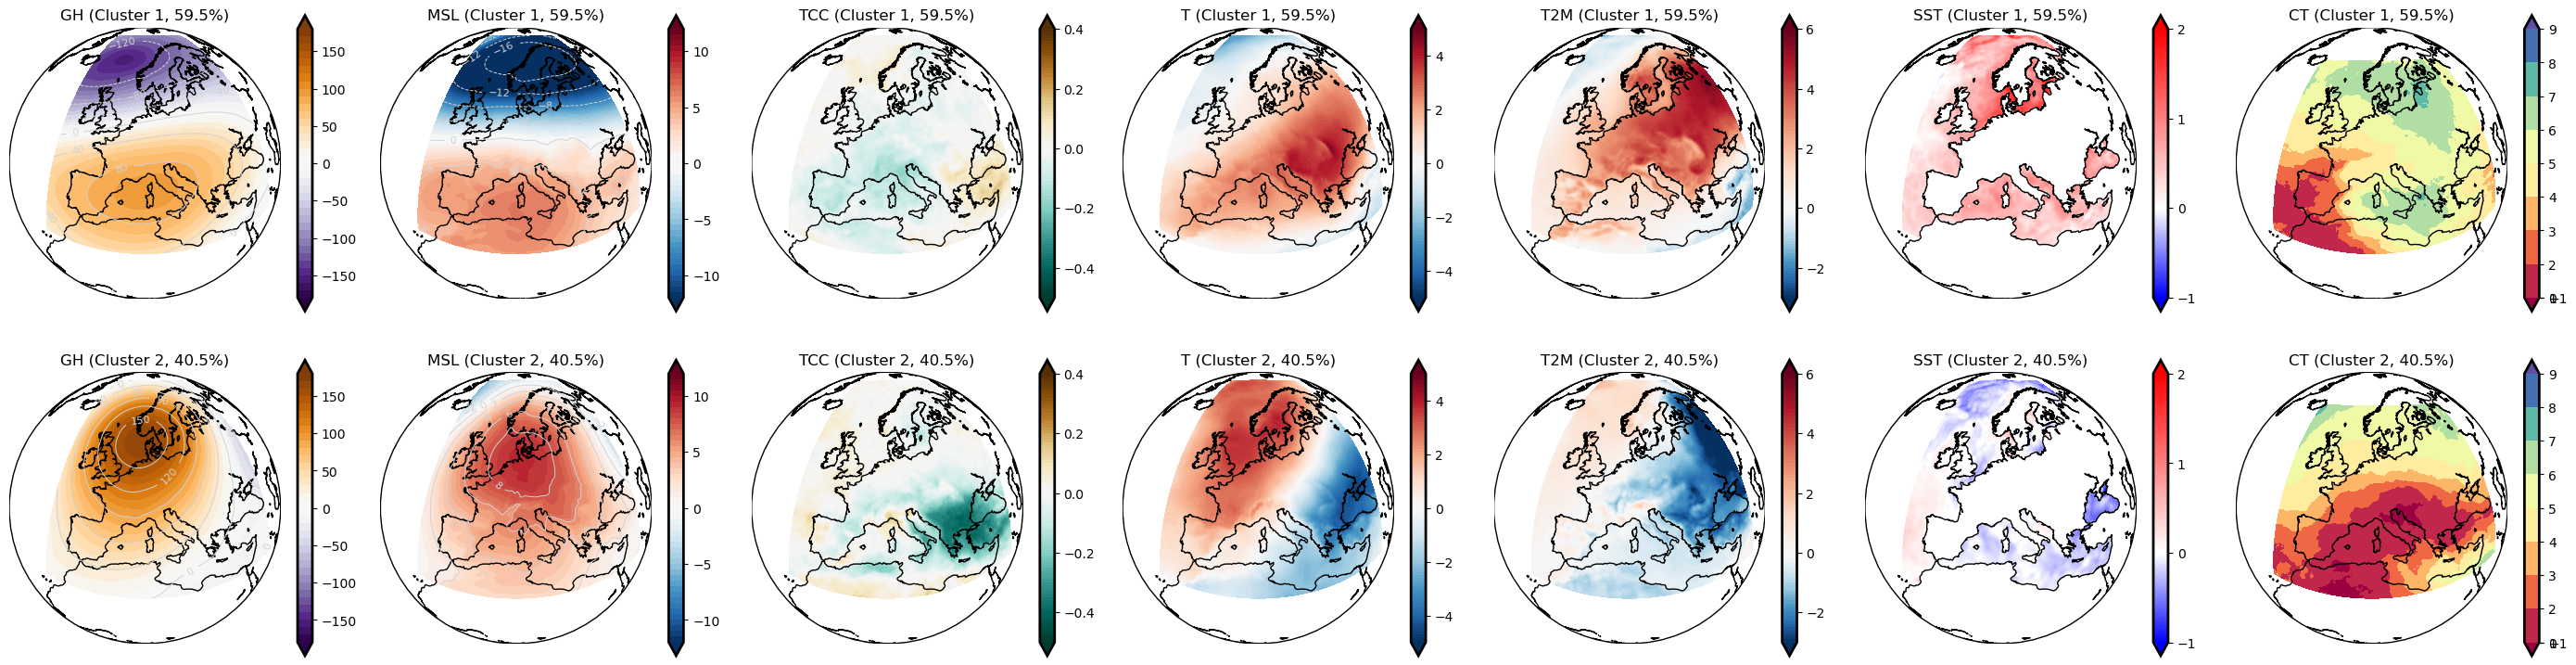

In [19]:
# Variable-specific plotting settings
variables = ['gh','msl','tcc','t','t2m','sst','CT']

colormaps = ['PuOr_r','RdBu_r','BrBG_r','RdBu_r','RdBu_r','bwr','Spectral']
counts = [1,1,0,0,0,0,0]
npas = [10,0.5,0.01,0.1,0.1,0.01,1]
vmins = [-180,-12,-0.5,-5,-3,-1,1]
vmaxs = [180,12,0.4,5,6,2,9]
tick_arrays = [
    [-150,-100,-50,0,50,100,150],
    [-10,-5,0,5,10],
    [-0.4,-0.2,0,0.2,0.4],
    [-4,-2,0,2,4],
    [-2,0,2,4,6],
    [-1,0,1,2],
    np.arange(-1,10,1)
]

# Run clustering
results = multivariate_kmeans(ds_ls_extreme_stacked, variables)


# # Prepare composites and frequencies
composites, freqs = prepare_composites_for_plot(results, variables, n_clusters=2)

# Plot
plot_all_variables(composites, variables, freqs,
                   colormaps=colormaps,
                   counts=counts,
                   npas=npas,
                   vmins=vmins,
                   vmaxs=vmaxs,
                   tick_arrays=tick_arrays)
